In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import defaultdict

SEED = 42
np.random.seed(SEED)

# Load MTA dataset
df = pd.read_csv('../data/processed/df_mta.csv', parse_dates=['touchpoint_date'])

print(df.shape)
print(df.head())
print(f"\nChannels: {df['channel'].unique()}")
print(f"Total users: {df['user_id'].nunique()}")
print(f"Converted users: {df[df['conversion']==1]['user_id'].nunique()}")

(35692, 4)
   user_id touchpoint_date      channel  conversion
0        0      2023-07-15      display           0
1        0      2023-07-16  paid_search           0
2        0      2023-07-17    affiliate           0
3        0      2023-07-18  paid_search           0
4        0      2023-07-19  paid_social           0

Channels: <ArrowStringArray>
['display', 'paid_search', 'affiliate', 'paid_social', 'organic']
Length: 5, dtype: str
Total users: 10000
Converted users: 2777


In [2]:
# ── Build user journeys ───────────────────────────────────────────────────────

# Group touchpoints into paths per user
journeys = (
    df.sort_values(['user_id', 'touchpoint_date'])
      .groupby('user_id')
      .agg(
          path=('channel', list),
          converted=('conversion', 'max')
      )
      .reset_index()
)

print(journeys.shape)
print(journeys.head(10))
print(f"\nConverted journeys: {journeys['converted'].sum()}")
print(f"Non-converted journeys: {(journeys['converted'] == 0).sum()}")

(10000, 3)
   user_id                                               path  converted
0        0  [display, paid_search, affiliate, paid_search,...          0
1        1           [display, organic, paid_search, organic]          0
2        2            [paid_search, paid_social, paid_search]          1
3        3              [paid_search, affiliate, paid_search]          1
4        4  [display, paid_social, display, paid_social, p...          0
5        5                             [display, paid_social]          0
6        6                             [organic, paid_search]          1
7        7                             [display, paid_search]          0
8        8            [paid_search, paid_social, paid_search]          0
9        9                                          [display]          0

Converted journeys: 2777
Non-converted journeys: 7223


In [3]:
# ── Baseline Attribution Models ───────────────────────────────────────────────

converted = journeys[journeys['converted'] == 1].copy()
channels = ['paid_search', 'paid_social', 'display', 'affiliate', 'organic']

last_touch  = defaultdict(float)
first_touch = defaultdict(float)
linear      = defaultdict(float)

for _, row in converted.iterrows():
    path = row['path']
    
    # Last Touch — 100% credit to last channel
    last_touch[path[-1]] += 1
    
    # First Touch — 100% credit to first channel
    first_touch[path[0]] += 1
    
    # Linear — equal credit split across all channels in path
    credit = 1.0 / len(path)
    for ch in path:
        linear[ch] += credit

# Normalize to percentages
total = converted.shape[0]

df_baseline = pd.DataFrame({
    'channel': channels,
    'last_touch':  [last_touch[ch]  / total * 100 for ch in channels],
    'first_touch': [first_touch[ch] / total * 100 for ch in channels],
    'linear':      [linear[ch]      / total * 100 for ch in channels],
})

print(df_baseline.round(2))

       channel  last_touch  first_touch  linear
0  paid_search       54.92        34.35   40.15
1  paid_social       25.42        26.68   25.15
2      display        2.20        20.60   13.67
3    affiliate        9.47        11.13   11.02
4      organic        7.99         7.24   10.02


In [4]:
# ── Markov Chain Attribution ──────────────────────────────────────────────────

def build_transition_matrix(journeys):
    """Build state transition probability matrix from user journeys."""
    
    transitions = defaultdict(lambda: defaultdict(float))
    
    for _, row in journeys.iterrows():
        path = row['path']
        converted = row['converted']
        
        # Add Start state
        full_path = ['Start'] + path + ['Conversion' if converted else 'Null']
        
        # Count transitions between consecutive states
        for i in range(len(full_path) - 1):
            transitions[full_path[i]][full_path[i+1]] += 1
    
    # Normalize to probabilities
    transition_probs = {}
    for state, next_states in transitions.items():
        total = sum(next_states.values())
        transition_probs[state] = {
            next_state: count / total
            for next_state, count in next_states.items()
        }
    
    return transition_probs


def conversion_rate(transition_probs, n_simulations=200000):
    """Estimate overall conversion rate via Monte Carlo simulation."""
    
    conversions = 0
    
    for _ in range(n_simulations):
        state = 'Start'
        
        while state not in ('Conversion', 'Null'):
            next_states = transition_probs.get(state, {'Null': 1.0})
            state = np.random.choice(
                list(next_states.keys()),
                p=list(next_states.values())
            )
        
        if state == 'Conversion':
            conversions += 1
    
    return conversions / n_simulations


def removal_effect(transition_probs, channel, n_simulations=200000):
    """Calculate conversion rate with channel removed from transition matrix."""
    
    # Build modified matrix excluding the target channel
    modified = {}
    for state, next_states in transition_probs.items():
        if state == channel:
            continue
        
        # Remove transitions TO the removed channel
        filtered = {
            next_s: prob
            for next_s, prob in next_states.items()
            if next_s != channel
        }
        
        # If all transitions removed — send to Null
        if not filtered:
            filtered = {'Null': 1.0}
        else:
            # Renormalize
            total = sum(filtered.values())
            filtered = {k: v / total for k, v in filtered.items()}
        
        modified[state] = filtered
    
    return conversion_rate(modified, n_simulations)


# Build matrix and calculate attribution
print("Building transition matrix...")
trans_matrix = build_transition_matrix(journeys)

print("Calculating base conversion rate...")
base_cr = conversion_rate(trans_matrix)
print(f"Base conversion rate: {base_cr:.3f}")

print("\nCalculating removal effects per channel...")
markov_attribution = {}
for ch in channels:
    cr_without = removal_effect(trans_matrix, ch)
    markov_attribution[ch] = max(0, (base_cr - cr_without) / base_cr)
    print(f"  {ch}: {markov_attribution[ch]:.3f}")

# Normalize to percentages
total_attr = sum(markov_attribution.values())
df_markov = pd.DataFrame({
    'channel': channels,
    'markov': [markov_attribution[ch] / total_attr * 100 for ch in channels]
})

print("\nMarkov Chain Attribution:")
print(df_markov.round(2))

Building transition matrix...
Calculating base conversion rate...
Base conversion rate: 0.276

Calculating removal effects per channel...
  paid_search: 0.252
  paid_social: 0.029
  display: 0.000
  affiliate: 0.000
  organic: 0.000

Markov Chain Attribution:
       channel  markov
0  paid_search   89.55
1  paid_social   10.45
2      display    0.00
3    affiliate    0.00
4      organic    0.00


In [5]:
# ── Shapley Value Attribution ─────────────────────────────────────────────────

from itertools import combinations

def conversion_rate_subset(journeys_converted, channel_subset):
    """
    Estimate conversion rate when only channels in subset are present.
    Users whose paths contain at least one channel from subset are counted.
    """
    if not channel_subset:
        return 0.0
    
    subset = set(channel_subset)
    total = len(journeys_converted)
    converted = sum(
        1 for _, row in journeys_converted.iterrows()
        if any(ch in subset for ch in row['path'])
    )
    return converted / total


def shapley_values(journeys, channels):
    """Calculate Shapley values for each channel."""
    
    converted = journeys[journeys['converted'] == 1]
    n = len(channels)
    shapley = {ch: 0.0 for ch in channels}
    
    for ch in channels:
        other_channels = [c for c in channels if c != ch]
        
        # Iterate over all subsets of other channels
        for size in range(len(other_channels) + 1):
            for subset in combinations(other_channels, size):
                subset = list(subset)
                
                # Marginal contribution of ch
                with_ch    = conversion_rate_subset(converted, subset + [ch])
                without_ch = conversion_rate_subset(converted, subset)
                marginal   = with_ch - without_ch
                
                # Shapley weight for this subset size
                import math
                weight = (
                    math.factorial(size) *
                    math.factorial(n - size - 1) /
                    math.factorial(n)
                )
                
                shapley[ch] += weight * marginal
    
    return shapley


# Calculate Shapley values
print("Calculating Shapley values...")
shapley_raw = shapley_values(journeys, channels)
print("Raw Shapley values:", {k: round(v, 4) for k, v in shapley_raw.items()})

# Normalize to percentages
total_shapley = sum(v for v in shapley_raw.values() if v > 0)
df_shapley = pd.DataFrame({
    'channel': channels,
    'shapley': [
        round(max(0, shapley_raw[ch]) / total_shapley * 100, 2)
        for ch in channels
    ]
})

print("\nShapley Value Attribution:")
print(df_shapley.round(2))

Calculating Shapley values...
Raw Shapley values: {'paid_search': 0.3852, 'paid_social': 0.2478, 'display': 0.1434, 'affiliate': 0.1159, 'organic': 0.1077}

Shapley Value Attribution:
       channel  shapley
0  paid_search    38.52
1  paid_social    24.78
2      display    14.34
3    affiliate    11.59
4      organic    10.77


In [6]:
# ── Comparative Visualization ─────────────────────────────────────────────────

# Combine all results into one dataframe
df_results = df_baseline.copy()
df_results = df_results.merge(df_markov, on='channel')
df_results = df_results.merge(df_shapley, on='channel')

# Add ground truth for reference
ground_truth = {
    'paid_search': 44.0,
    'paid_social': 18.0,
    'display':     2.0,
    'affiliate':   8.0,
    'organic':     4.0
}
df_results['ground_truth'] = df_results['channel'].map(ground_truth)

print(df_results.round(2))

       channel  last_touch  first_touch  linear  markov  shapley  ground_truth
0  paid_search       54.92        34.35   40.15   89.55    38.52          44.0
1  paid_social       25.42        26.68   25.15   10.45    24.78          18.0
2      display        2.20        20.60   13.67    0.00    14.34           2.0
3    affiliate        9.47        11.13   11.02    0.00    11.59           8.0
4      organic        7.99         7.24   10.02    0.00    10.77           4.0


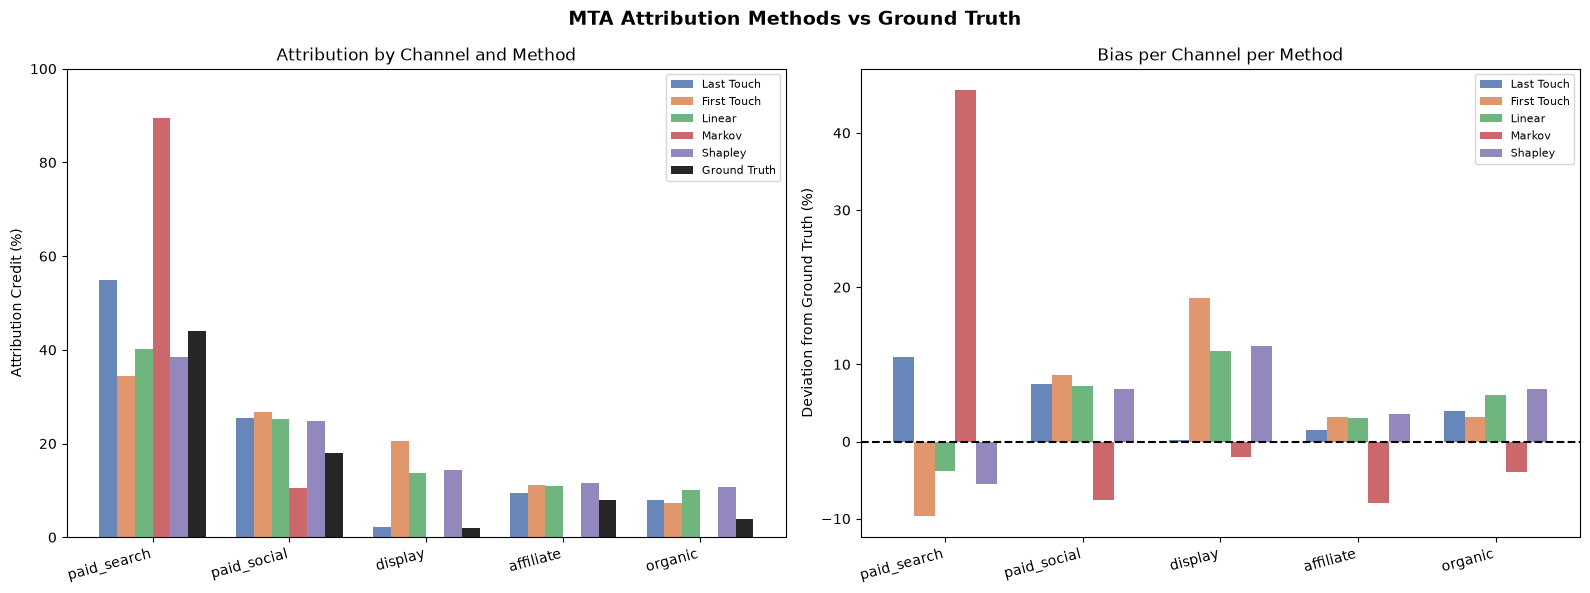

Saved: mta_comparison.png


In [7]:
# ── Plot: All MTA methods vs Ground Truth ─────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('MTA Attribution Methods vs Ground Truth', fontsize=14, fontweight='bold')

# --- Chart 1: Grouped bar chart ---
methods = ['last_touch', 'first_touch', 'linear', 'markov', 'shapley', 'ground_truth']
labels  = ['Last Touch', 'First Touch', 'Linear', 'Markov', 'Shapley', 'Ground Truth']
colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#000000']

x = np.arange(len(channels))
width = 0.13

ax1 = axes[0]
for i, (method, label, color) in enumerate(zip(methods, labels, colors)):
    offset = (i - len(methods) / 2) * width + width / 2
    bars = ax1.bar(x + offset, df_results[method], width, label=label, color=color, alpha=0.85)

ax1.set_xticks(x)
ax1.set_xticklabels(df_results['channel'], rotation=15, ha='right')
ax1.set_ylabel('Attribution Credit (%)')
ax1.set_title('Attribution by Channel and Method')
ax1.legend(loc='upper right', fontsize=8)
ax1.set_ylim(0, 100)
ax1.axhline(y=0, color='black', linewidth=0.5)

# --- Chart 2: Deviation from Ground Truth ---
ax2 = axes[1]
method_cols   = ['last_touch', 'first_touch', 'linear', 'markov', 'shapley']
method_labels = ['Last Touch', 'First Touch', 'Linear', 'Markov', 'Shapley']
method_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

x2 = np.arange(len(channels))
width2 = 0.15

for i, (method, label, color) in enumerate(zip(method_cols, method_labels, method_colors)):
    deviation = df_results[method] - df_results['ground_truth']
    offset = (i - len(method_cols) / 2) * width2 + width2 / 2
    ax2.bar(x2 + offset, deviation, width2, label=label, color=color, alpha=0.85)

ax2.set_xticks(x2)
ax2.set_xticklabels(df_results['channel'], rotation=15, ha='right')
ax2.set_ylabel('Deviation from Ground Truth (%)')
ax2.set_title('Bias per Channel per Method')
ax2.legend(loc='upper right', fontsize=8)
ax2.axhline(y=0, color='black', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.savefig('../data/processed/mta_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mta_comparison.png")